In [2]:
suppressMessages(library(effects))

ratpup           <- read.table('rat_pup.dat', header=TRUE)
ratpup$sex       <- as.factor(ratpup$sex)
ratpup$litter    <- as.factor(ratpup$litter)
ratpup$treatment <- as.factor(ratpup$treatment)

# Building the Model II
In our second model building step, we need to take the single model we specified in the previous step and expand it to allow for *multiple* dependency structures. In context, this means generalising our model of a *single* litter to a model of *multiple* litters. In doing so, we aim to decide which parameters we allow to vary from litter-to-litter and which parameters we want to stay fixed across all litters.


## The Multiple Litters Model
If we start with our model from the previous step

$$
y_{ij} = \mu + \alpha_{j} + \eta_{ij}
$$

we now need to imagine that there are *multiple* litters and rewrite the model accordingly. To do so, we need another index to make it clear *which litter* the model is referring to. We will use $k$ to indicate `litter`, but will use a slightly different notation to illustrate which elements *belong* to the model for litter $k$. So, we generalise the model above for litter $k$ as

$$
y^{(k)}_{ij} = \mu^{(k)} + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}
$$

This indicates that *everything* in the model depends upon the specific litter. Each litter has its own individual measures of weight $\left(y_{ij}\right)$, mean weight $\left(\mu\right)$, effect of sex $\left(\alpha_{j}\right)$ and errors $\left(\eta_{ij}\right)$. This is generally our starting-point, but we will decide below whether to keep things this way or not.

## Specifying Multiple Models in `R`
We can get a clearer picture of expanding our model to multiple litters using `R`. Like the illustrations in the previous step this is not wholly necessary, but can be a useful device for gaining intuition. In doing so, we conceptualise $(k)$ as the index of a loop over litters. In the code below, we show this by building a list of models by iteratively subsetting the data based on individual litters. The only catch is that some letters contain only a single level of `sex`, which will cause the model to fail. To get around this, we use the `try()` function, which will attempt to fit the model but will not cause the code to crash if there is an error. We include `silent=TRUE` so that no errors are printed if a model does fail.

In [3]:
litter.mods <- list()  
litters     <- unique(ratpup$litter)
n.litters   <- length(litters)

for(k in 1:n.litters){
  litter.k <- subset(ratpup, litter==as.character(litters[k]))
  try(
    litter.mods[[k]] <- lm(weight ~ sex, data=litter.k), 
    silent=TRUE
  )
}

We can now visualise each of these individual models to provide a sense of what generalising our model across litters means.

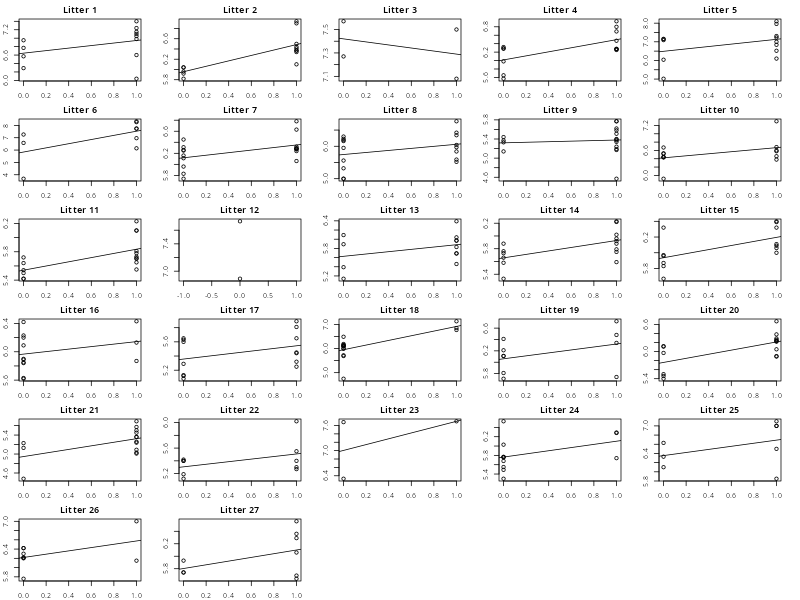

In [4]:
par(mfrow=c(6,5), mar=c(2,2,2,2))
for(k in 1:n.litters){
  litter.k  <- subset(ratpup, litter==as.character(litters[k]))
  sex.dummy <- as.numeric(litter.k$sex) - 1
  plot(sex.dummy, litter.k$weight, main=paste0('Litter ', k))
  if (!is.null(litter.mods[[k]])){
    abline(reg=litter.mods[[k]])
  }
}

As we can see, each litter is unique in terms of its data. Notable cases include litter 12 that has no male pups, and litter 23 that only has a single male pup. Each litter also has a slightly different scale on the $y$-axis, indicative of the fact that the mean weight of each litter will vary from mother-to-mother. Also of note is that the regression slope between female and male pups is different in each litter. However, there is a general pattern here for males being *heavier* than females. This is not universal, however, there is an important conceptual point about whether we think these slopes differ because the effect of sex is genuinely different for each litter, or is there actually a universal effect of sex on weight across all the litters and all we are seeing here is sampling noise? We will discuss this further below. 

## Identifying Which Terms are *Random*
Now that we have our model for each level of `litter`, we need to make some decisions. As indicated above, every element has the *potential* to be different for each litter. Of course, the data itself always will be, as will the errors. So our question is about how to treat those elements that form the *mean function* of each litter:

$$
E\left(y^{(k)}_{ij}\right) = \mu^{(k)} + \alpha^{(k)}_{j}
$$

For each of these term, we have a *choice*. Do we imagine that this effect changes with each litter, or do we want to treat it as a *global* effect that is assumed to be the *same* across all litters? 

In making this decision, we are trying to capture *why* the `litter` variable matters. What influence does `litter` have on the weight of the pups within it? Any element that *changes* from litter-to-litter captures why `litter` influences `weight`, whereas any element that is the *same* suggests that `litter` is irrelevant. So, we are asking whether `litter` influences `weight` by causing the average weight of all pups to shift up or down $\left(\mu\right)$ and whether `litter` also influences `weight` by changing the difference between male and female pups $\left(\alpha_{j}\right)$.   


````{admonition} Reasoning About the Problem
:class: tip
As will hopefully become clear, there is no *absolute truth* here. These decisions have to be made by reasoning about the problem and considering what the model is saying, given the choices we make. Although we can use model comparisons to see which choice is most compatible with the data, we also need to start from a position of justifying our choices. If you are working alongside domain experts on the analysis, this is the sort of conversation you can have to pick the options that are most plausible. So there is no shortcut to engaging your brain and thinking about the problem in front of you. This can be difficult, but is part of the reality of analysing data. 
````

### Should the Intercept be Random?
To start with, let us consider how to treat $\mu^{(k)}$. This is the *average weight* per-litter. So, from a purely *theoretical* perspective, do we think that the reason that `litter` is important is because it influences the average weight of the pups within each litter? Alternatively, do we think that all litters would eventually converge on the *same* weight and that the litter itself has no bearing on average weight? 

Our choice here is effectively between the following models. Either we allow $\mu$ to change from litter-to-litter 

$$
y^{(k)}_{ij} = \mu^{(k)} + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}
$$

or we fix $\mu$ to the same value for each litter

$$
y^{(k)}_{ij} = \mu + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}.
$$


To think about this more clearly, imagine that we were able to take *two* mother rats and make them give birth to new litters over and over again. Our key question is whether we believe that 

1. Over time the average weight of all the litters, irrespective of their mother and rearing environment, will converge on the *same value*. In other words, the mother and rearing environment *does not matter*. Any discrepancy in our measurements is simply sampling variation that is unrelated to each mother and rearing environment.
2. Over time, the average weight of all litters from the same mother will converge on their own *unique* value that will be different from another mother. In other words, the mother and rearing environment *does* matter. For instance, mother rat A always produces litters that are heavier on average than mother rat B. Any discrepancy in our measurements is then a mixture of sampling variation *and* the effect of a specific mother and rearing environment.

This is precisely the choice between treating the mean weight per-litter as a *constant* across litters or as unique *per-litter*. Our question is which of these descriptions of reality is more plausible?

For this example, it is probably not sensible to constrain all litters to the same expected weight. Depending upon different genetic factors and birthing conditions, some litters will be heavier or lighter than others. This goes beyond just random sampling noise and becomes a systematic source of variation that directly relates to the different litters. Mother rats themselves will be different weights and sizes which will place constraints on the average weight and size of their pups. Indeed, this was the whole reason for characterising `litter` as a clustering variable in the first place. We can see this in the plots from earlier where each litter had a different *scaling* on the $y$-axis. This is precisely the aspect that a random intercept will capture. So, in this instance, we will argue that it makes most sense to allow $\mu$ to differ per-litter. 

In general, irrespective of whether we are dealing with *clusters* or *subjects*, it is *almost always* sensible to start with this assumption, which is known very generally as a *random-intercepts* model.

### Should the Slope be Random?
Now, we need to provide the same consideration to $\alpha^{(k)}_{j}$. Remember, this is the *effect* of `sex` on `weight` *per-litter*. However, unlike the random intercept, the decision about how to treat $\alpha^{(k)}_{j}$ is less clear-cut. Again, our choice is between a model that allows $\alpha_{j}$ to change from litter-to-litter

$$
y^{(k)}_{ij} = \mu^{(k)} + \alpha^{(k)}_{j} + \epsilon^{(k)}_{ij}
$$

or a model where $\alpha_{j}$ is assumed to have the same influence on each litter

$$
y^{(k)}_{ij} = \mu^{(k)} + \alpha_{j} + \epsilon^{(k)}_{ij}.
$$

To think about this more clearly, we need to consider what the two options are suggesting about the way the world operates. Do we think that there is a universal effect of `sex` on `weight` that is always there, irrespective of genetics or rearing environment? A general effect of "males are heavier than females", that does not depend upon the specific mother rat? Alternatively, do we believe that the effect of `sex` on `weight` depends upon a specific mother rat and rearing environment? Could it be that some mother rats within a specific rearing environment will always produce female pups that are heavier than male pups?

Of course, the problem here is that you could argue it *either way*. It very much depends on how strongly we believe that the effect of `sex` on `weight` is a homogeneous fact of biology that exists across litters, or how strongly we believe that there could be gene $\times$ environment interactions that change the effect of `sex` for different litters. Is it plausible that some mother rats may consistently have female pups that are *heavier* than male pups? Or female and male pups that are *equivalent* in weight? Or, is it more plausible to think that male pups will *always* be heavier than female pups and that any deviation from this relates to sampling noise, rather than something systematic that relates to a specific litter?

When faced with this sort of decision, we either have to (a) pick one possibility that we believe more strongly or (b) pick the most general case and then use model comparisons to see which the data supports. For this example, we will take the latter approach, which is to temporarily assume that the `sex` effect *could* differ per-litter. We will then use model comparisons a little later to see which approach the data favours[^sextextbook-foot].

## Does the Data Support What We Want?
Based on the reasoning above, we have stuck with our original conceptualisation that both the mean weight and effect of sex can differ on a per-litter basis. The model we *want* to fit at Level 1 is therefore

$$
y^{(k)}_{ij} = \mu^{(k)} + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}.
$$

Once we have made this decision, we need to examine the data from a *practical* perspective, to see if it can support both a different average value of `weight` per-litter and a different effect of `sex` per-litter. Even if we *want* to do this, that data needs to allow it. Although we have shown that this is possible already by fitting individual models earlier in the lesson, we now turn to how this decision can be made without using software to brute-force the decision.

In order to fit a random intercept, we require *at least* two values of `weight` on average per-litter. This guarantees that there is variance left over once $\mu^{(k)}$ has been fit. This means we need at least two pups within most litters. In this dataset, we can use the `litsize` variable to check this

In [5]:
mean(ratpup$litsize)

[1] 13.32919

So, there is an average of around 13 pups in each litter, meaning that a random-intercept term is perfectly feasible. So, we can conclude that both *theoretically* and *practically* we can allow a different baseline weight for each litter. Indeed, the only time this would *not* be possible would be if we only have one observation per-cluster or per-subject. This would lead us to fix the intercept and we would be back to the normal linear model. This makes sense because at that point there is no dependency in the data, we have just taken a bit of a circuitous route to get there.

In order to fit a random slope, we require an average of at least *two* male pups and *two* female pups per-litter. If each litter consisted of only a single male and a single female, the regression slope would simply be a line drawn from one data point to the other and there would be no variance left over. Similarly, if each litter consisted of only a single sex, there would be no slope to fit. Again, we can generate some summaries in `R` to check that these conditions are met.

In [7]:
xtabs(~ litter + sex, data=ratpup)

      sex
litter Female Male
    1       4    8
    2       5    9
    3       2    2
    4       6    8
    5       5    8
    6       3    6
    7       9    9
    8       9    8
    9       4   13
    10      7    6
    11      6   10
    12      2    0
    13      4    8
    14      6    9
    15      6    7
    16     10    3
    17      7    7
    18     12    3
    19      6    4
    20      6   10
    21      3   11
    22      5    5
    23      2    1
    24      9    3
    25      3    5
    26      7    2
    27      3    6

So, we can see that the vast majority of litters have at least 2 male and 2 female pups. This indicates that there should be enough variation on average per-litter to allow a random slope. Even if there was not, we would soon find out because the model would fail to fit. However, we can avoid this embarrassment by trying to reason about it first. Although tempting to brute-force these decisions by examining when the model fails, this is not a good strategy because it suggests a lack of *understanding* about the model. If the model fails for reasons that are not related to the optimisation strategy, then you have asked the model to do something that it cannot and should understand why.

### What if the Data Does Not Support the Model?
Although this example dataset *does* support what we want, we also need to consider what to do if the data *does not* support what we want. The most common example of this would be repeated measurements without replication. Although we may wish to treat the effect of the repeated measures conditions as *random*, if we only have a single replication per-repeated then we do not have the variance to allow this. This would be similar to if each litter only contained *one* male and *one* female rat pup. In these situations, we are *forced* by the data to assume that the effect is *fixed*. So, the decision making is taken out of our hands. We need to assume that it is the same effect across dependency structures because we do not have enough information within each structure to estimate the effect uniquely. We need to force the pooling of information to allow anything to be estimated. This is not desirable because we cannot make a decision here and our hand is forced. Nevertheless, the process should be clear. Even if we want a term to be random, if the data does not support this then we need to make it *fixed*. This was demonstrated last week for the model of the `anxiety` dataset from `datarium`, we just did not present it as such at that point.

### Missing Data
Another important clarification is that the above decisions were made in relation to the *average* data per-litter. This is important. We do not require this to be true of *all* litters. Indeed, we can still fit a random intercept model, even if some litters only contain a single data point. Similarly, we can fit a random slope model, even if some litters contain no male pups or no female pups. Remember, multilevel/mixed-effects models allow for this via pooling and shrinkage. So if a particular litter does not have the data to support an effect on its own, its estimate will be *shrunk* towards the average. For example, we saw above that litter 12 had *no* male pups. Although this prevented an effect of `sex` being fit to that data in isolation, when estimated as a whole with all the other litters, the multilevel model will *create* an effect of `sex` for that litter. This will be derived by pooling information across litters . This is what allows these types of models to be so powerful when data is missing. We will see this demonstrated when we examine the model fit in `R` a little later.

`````{topic} What do you now know?
In this section, we have complete Step II in our model building process. After reading this section, you should have a good sense of :

- The concept of expanding the model for Step I to multiple dependency structures.
- The idea that we can start by allowing *everything* to vary from structure-to-structure by adding an index $(k)$.
- The idea that we then need to *justify* this choice by deciding whether a term should remain *random* or should be *fixed*.
- The key concept that this is a *modelling* decision, not a fact of the universe. The key is deciding what these decisions *imply* about the way the world operates.
- The key concept that the *bare minimum* of most mixed-effects models is a *random intercept* term.
- The key idea that the data needs to support what we want, otherwise we are *forced* to make terms *fixed*, even if we do not want to.
- The key idea that we only require enough data *on average* within structures. Missing data is allowed and will be inferred by pooling across structures.

`````

[^sextextbook-foot]: It is interesting to note that, in their description of this analysis, [West, Welch & Galecki (2022)](https://www.taylorfrancis.com/books/mono/10.1201/9781003181064/linear-mixed-models-brady-west-kathleen-welch-andrzej-galecki?context=ubx&refId=4dbda113-7f59-4ba9-a710-897ef536cfee) make the decision to fix `sex` to a constant across litters, under the belief that there is a universal effect of `sex` on weight that is not influenced by individual litters. Rather than jumping straight to that decision, we have kept things more general and will examine whether this assumption is justified later by using model comparisons. This highlights that there is no *universal truth* here in terms of building these models and that different analysts may take different approaches and make different decisions along the way.